In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow version: {tf.__version__}")
if gpus:
    print(f"GPU found: {gpus[0].name} ")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("No GPU found — using CPU")

df = pd.read_csv('C:/data/BrandPulse-AI/data/processed/cleaned_tweets.csv')
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']

print(f"\nDataset shape: {df.shape}")
print(f"Positive: {(df['polarity']==1).sum()}")
print(f"Negative: {(df['polarity']==0).sum()}")

TensorFlow version: 2.21.0
No GPU found — using CPU

Dataset shape: (1592958, 3)
Positive: 796242
Negative: 796716


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import json

VOCAB_SIZE = 20000
MAX_LEN = 100
EMBEDDING_DIM = 128

X = df['cleaned_text'].values
y = df['polarity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {len(X_train)} tweets")
print(f"Testing:  {len(X_test)} tweets")

print("\nFitting tokenizer...")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)} unique words")
print(f"Using top {VOCAB_SIZE} words")

os.makedirs('C:/data/BrandPulse-AI/models', exist_ok=True)
tokenizer_json = tokenizer.to_json()
with open('C:/data/BrandPulse-AI/models/tokenizer.json', 'w') as f:
    f.write(tokenizer_json)
print("Tokenizer saved ")

Training: 1274366 tweets
Testing:  318592 tweets

Fitting tokenizer...
Vocabulary size: 348569 unique words
Using top 20000 words
Tokenizer saved 


In [4]:
print("Converting text to sequences...")
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print("Padding sequences...")
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape:  {X_test_pad.shape}")

print(f"\nOriginal tweet: {X_train[0]}")
print(f"As sequence:    {X_train_seq[0][:10]}...")
print(f"Padded:         {X_train_pad[0][:10]}...")

Converting text to sequences...
Padding sequences...
X_train_pad shape: (1274366, 100)
X_test_pad shape:  (318592, 100)

Original tweet: listening music wishing could hang richard tonight
As sequence:    [260, 226, 599, 79, 560, 3893, 63]...
Padded:         [ 260  226  599   79  560 3893   63    0    0    0]...


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional,
                                     LSTM, Dense, Dropout,
                                     GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam

def build_lstm_model(vocab_size, embedding_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  input_length=max_len),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
model.summary()

C:\Users\pradh\miniconda3\envs\brandpulse\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ embedding (Embedding)         │ ?                     │  0 (unbuilt) │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ ?                     │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bidirectional (Bidirectional) │ ?                     │  0 (unbuilt) │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_1 (Dropout)           │ ?                     │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ global_max_pooling1d          │ ?                     │            0 │
│ (GlobalMaxPooling1D)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ ?                     │  0 (unbuilt) │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_2 (Dropout)           │ ?                     │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ ?                     │  0 (unbuilt) │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import (EarlyStopping,
                                         ModelCheckpoint,
                                         ReduceLROnPlateau)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'C:/data/BrandPulse-AI/models/lstm_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

print("Training LSTM model on CPU...")
print("This will take 20-25 minutes — let it run fully!")

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("\nTraining complete! ")

Training LSTM model on CPU...
This will take 20-25 minutes — let it run fully!
Epoch 1/10
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7623 - loss: 0.4856
Epoch 1: val_accuracy improved from None to 0.80469, saving model to C:/data/BrandPulse-AI/models/lstm_best.h5


2241/2241 ━━━━━━━━━━━━━━━━━━━━ 747s 332ms/step - accuracy: 0.7880 - loss: 0.4522 - val_accuracy: 0.8047 - val_loss: 0.4295 - learning_rate: 0.0010
Epoch 2/10
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8115 - loss: 0.4131
Epoch 2: val_accuracy improved from 0.80469 to 0.80706, saving model to C:/data/BrandPulse-AI/models/lstm_best.h5


2241/2241 ━━━━━━━━━━━━━━━━━━━━ 751s 335ms/step - accuracy: 0.8108 - loss: 0.4139 - val_accuracy: 0.8071 - val_loss: 0.4238 - learning_rate: 0.0010
Epoch 3/10
2240/2241 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8201 - loss: 0.3963
Epoch 3: val_accuracy improved from 0.80706 to 0.80986, saving model to C:/data/BrandPulse-AI/models/lstm_best.h5


2241/2241 ━━━━━━━━━━━━━━━━━━━━ 749s 334ms/step - accuracy: 0.8187 - loss: 0.3991 - val_accuracy: 0.8099 - val_loss: 0.4154 - learning_rate: 0.0010
Epoch 4/10
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.8270 - loss: 0.3827
Epoch 4: val_accuracy did not improve from 0.80986
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 733s 327ms/step - accuracy: 0.8250 - loss: 0.3866 - val_accuracy: 0.8095 - val_loss: 0.4166 - learning_rate: 0.0010
Epoch 5/10
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.8329 - loss: 0.3712
Epoch 5: val_accuracy did not improve from 0.80986

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 1466s 654ms/step - accuracy: 0.8313 - loss: 0.3746 - val_accuracy: 0.8087 - val_loss: 0.4186 - learning_rate: 0.0010
Epoch 6/10
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8428 - loss: 0.3512
Epoch 6: val_accuracy did not improve from 0.80986
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 758s 338ms/step - accuracy:

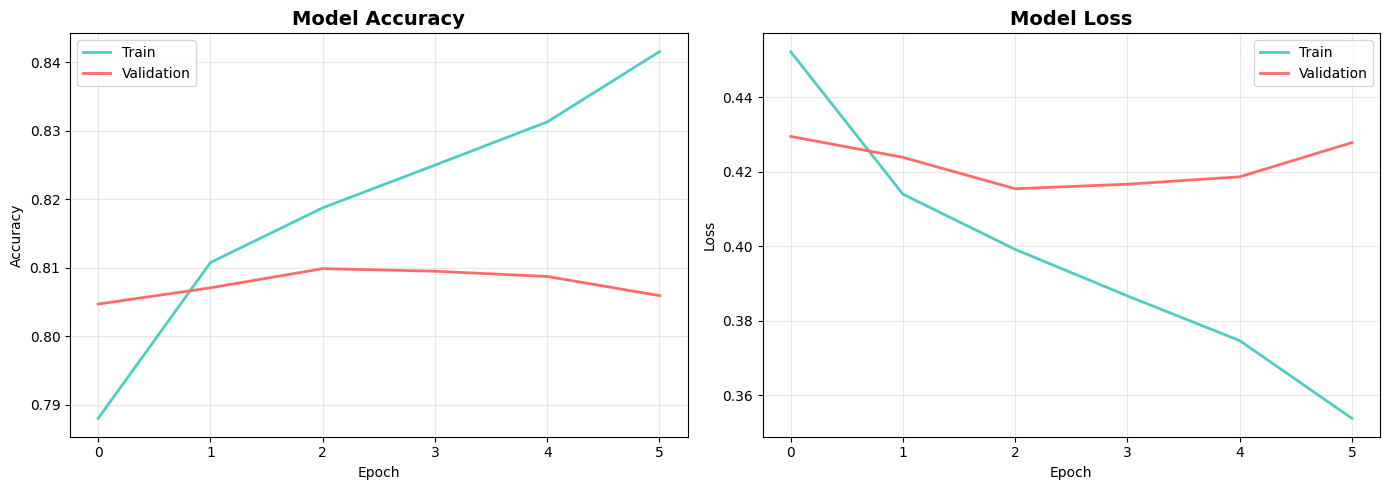

Saved lstm_training_curves.png 


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', color='#4ECDC4', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#FF6B6B', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='#4ECDC4', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#FF6B6B', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/data/BrandPulse-AI/reports/figures/lstm_training_curves.png', dpi=150)
plt.show()
print("Saved lstm_training_curves.png ")

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import json

# Parameters
VOCAB_SIZE = 20000
MAX_LEN = 100

# Load cleaned data
df = pd.read_csv('C:/data/BrandPulse-AI/data/processed/cleaned_tweets.csv')
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']

X = df['cleaned_text'].values
y = df['polarity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Load tokenizer
with open('C:/data/BrandPulse-AI/models/tokenizer.json') as f:
    tokenizer = tf.keras.preprocessing.text.tokenizer_from_json(f.read())

# Pad test sequences
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN,
                            padding='post', truncating='post')

# Load saved model
model = load_model('C:/data/BrandPulse-AI/models/lstm_best.h5')
print("Model loaded ✅")
print(f"Test set: {X_test_pad.shape}")

Model loaded ✅
Test set: (318592, 100)


Evaluating on test set...
623/623 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step

LSTM Accuracy: 0.8104 (81.04%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.81      0.81    159343
    Positive       0.81      0.81      0.81    159249

    accuracy                           0.81    318592
   macro avg       0.81      0.81      0.81    318592
weighted avg       0.81      0.81      0.81    318592



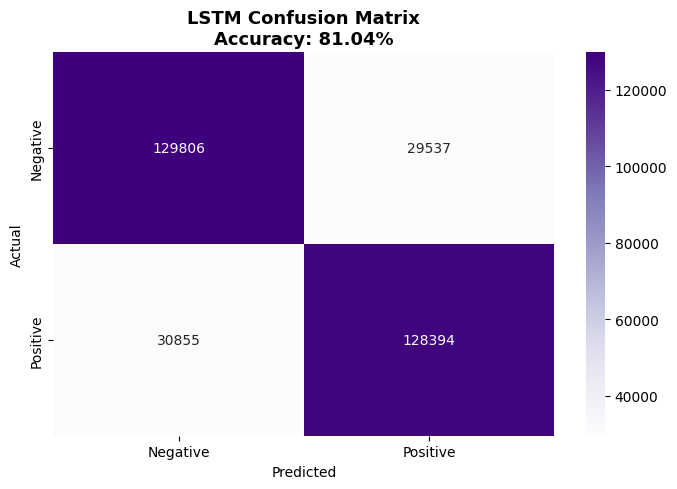

Saved! 


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating on test set...")
y_pred_prob = model.predict(X_test_pad, batch_size=512)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test, y_pred)
print(f"\nLSTM Accuracy: {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'LSTM Confusion Matrix\nAccuracy: {lstm_accuracy*100:.2f}%',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('C:/data/BrandPulse-AI/reports/figures/confusion_matrix_lstm.png', dpi=150)
plt.show()
print("Saved! ")